<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_0_Preliminaries/17_0_1_UnivariateSpread.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression Preliminaries: Univariate Spread

Author: Brad Sheese

---



## Before We Begin...

If you haven't previously had a statistics course that covered this material you may need to go beyond the readings and the exercises to get comfortable with regression as a tool. Fortunately, these days there are [all kinds of materials pitched at different audiences to help you out](https://www.youtube.com/results?search_query=simple+linear+regression). Poke around until your find something you like. If you get a bit frustrated, keep at it. If you get really frustrated, come ask for help. That's what we are here for.


## What This Notebook Is About

Before we can build a regression model, we need to answer a surprisingly deep question:

> **If you had to guess the value of something, with no other information to help you, what is the best guess you can make, and how wrong would you expect to be?**

Answering that question forces us to invent (or re-discover) four of the most important ideas in all of statistics:

1. **The Mean** — our *baseline* prediction.
2. **Errors (deviations)** — how wrong that baseline is for each data point.
3. **The Total Sum of Squares (TSS)** — the *total* error of the baseline.
4. **Variance and Standard Deviation** — the *average* error of the baseline, in useful units.

Everything we do later in regression is just a story about shrinking that error by using *other* information.


## Setup

We'll use the Palmer Penguins dataset (built into seaborn). Our variable of interest: `body_mass_g` which is the weight of each penguin in grams. We'll drop rows where the weight is missing so we have a clean 1D array to work with.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Load the Palmer Penguins dataset and pull out penguin body masses (in grams).
penguins = sns.load_dataset('penguins').dropna(subset=['body_mass_g'])
body_mass_g = penguins['body_mass_g'].to_numpy()

print(f'Number of penguins: {len(body_mass_g)}')
print(f'First 5 weights (g): {body_mass_g[:5]}')

Number of penguins: 342
First 5 weights (g): [3750. 3800. 3250. 3450. 3650.]


---

## Section 1: The Simplest Model (The Mean)

### The Scenario

Imagine you are a field researcher in Antarctica. A colleague radios in: *"We just caught a penguin. About to bring it into the tent. Guess its weight."*

You haven't seen the penguin. You don't know its species, its flipper length, or its sex. You know only one thing: you have a big spreadsheet of weights from penguins measured in the past.

**What is your best guess?**

### The Concept

In everyday life we think of the **mean** as just an "average". In data science, the mean is something much more powerful:

> **The mean is the Baseline Model.** When you have no features to help you predict an outcome, guessing the mean of your historical data is the prediction that minimizes your *squared* error, on average.

This is our first and simplest model. It has no inputs, no slopes, no coefficients. Every prediction is the same number. And yet, it's the starting line that every more complicated model has to beat.

In [ ]:
mean_mass = np.mean(body_mass_g)
print(f'Mean penguin body mass: {mean_mass:.2f} g')

Mean penguin body mass: 4201.75 g


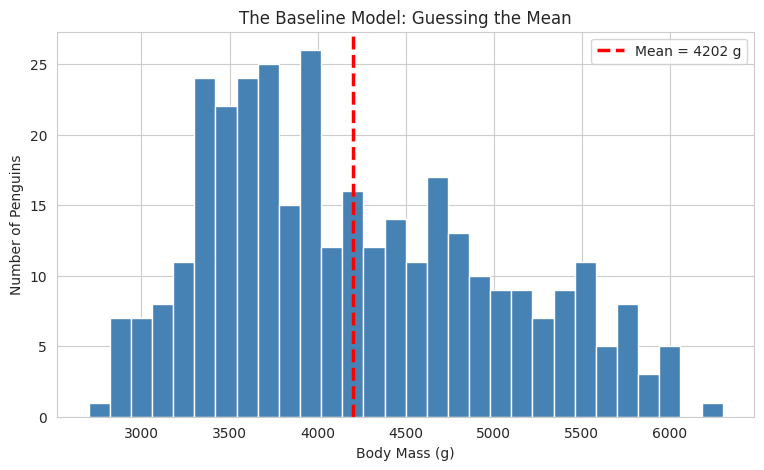

In [ ]:
# Visualize the baseline model:
# the histogram shows the actual distribution of penguin weights,
# and the dashed red line shows the single value our baseline model always predicts.
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(body_mass_g, bins=30, color='steelblue', edgecolor='white')
ax.axvline(mean_mass, color='red', linestyle='--', linewidth=2.5,
           label=f'Mean = {mean_mass:.0f} g')
ax.set_xlabel('Body Mass (g)')
ax.set_ylabel('Number of Penguins')
ax.set_title('The Baseline Model: Guessing the Mean')
ax.legend()
plt.show()

So our baseline model's prediction is **≈4207 g**, no matter which penguin walks into the tent.

But looking at the histogram, that's clearly not the *right* answer for every penguin. Some penguins weigh less than 3000g. Some weigh more than 6000g. Our single guess of 4207 is going to be wrong for almost every individual bird.

**The next question: how wrong is it, on average? To answer that, we have to measure our mistakes.**

---

## Section 2: Measuring the Error of the Mean

### The Formula

For each penguin $i$ in our dataset, the **error** (sometimes called the **deviation**) of the baseline model is simply the difference between that penguin's actual weight and our prediction (the mean):

$$\text{error}_i = y_i - \bar{y}$$

where:
- $y_i$ is the actual weight of penguin $i$
- $\bar{y}$ (pronounced "y-bar") is the mean weight

A positive error means the penguin was *heavier* than our guess. A negative error means it was *lighter*.

In [ ]:
errors = body_mass_g - mean_mass

# Look at the first 5 penguins: their actual weights alongside their errors
preview = pd.DataFrame({
    'actual_weight_g': body_mass_g[:5],
    'prediction_g':    np.full(5, mean_mass),
    'error_g':         errors[:5]
})
preview

,actual_weight_g,prediction_g,error_g
0,3750.0,4201.754386,-451.754386
1,3800.0,4201.754386,-401.754386
2,3250.0,4201.754386,-951.754386
3,3450.0,4201.754386,-751.754386
4,3650.0,4201.754386,-551.754386


### Seeing the Errors

A histogram is great at showing the *shape* of the data, but it hides the individual penguins, and it hides how far each one is from the mean. Let's make a different picture.

We'll take a random sample of 20 penguins and plot each one as a single point on a horizontal line. Then, for each penguin, we'll draw a line segment from the penguin's weight back to the mean. The length of that segment **is** the error for that penguin.

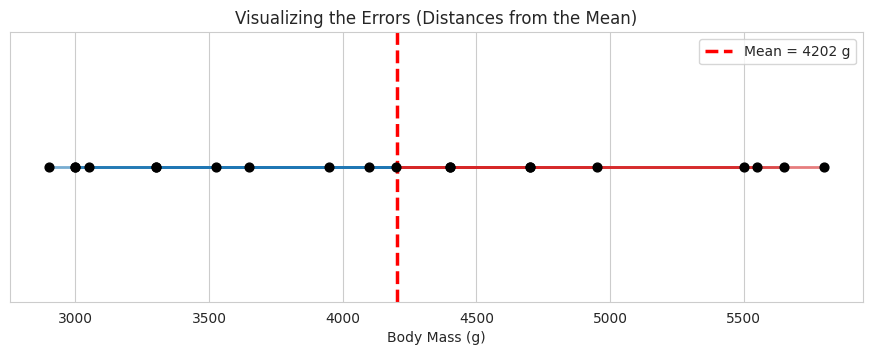

In [ ]:
# Grab 20 random penguins for a clean, uncluttered picture.
rng = np.random.default_rng(seed=42)
sample = rng.choice(body_mass_g, size=20, replace=False)

fig, ax = plt.subplots(figsize=(11, 3.5))

# For each penguin, draw a line segment from the penguin's weight to the mean.
for weight in sample:
    color = 'tab:red' if weight > mean_mass else 'tab:blue'
    ax.hlines(y=0, xmin=min(weight, mean_mass), xmax=max(weight, mean_mass),
              color=color, alpha=0.6, linewidth=2)

# Plot each penguin as a dot on the line.
ax.scatter(sample, np.zeros_like(sample), color='black', zorder=3, s=40)

# Draw the mean as a tall vertical marker.
ax.axvline(mean_mass, color='red', linestyle='--', linewidth=2.5,
           label=f'Mean = {mean_mass:.0f} g')

ax.set_yticks([])
ax.set_xlabel('Body Mass (g)')
ax.set_title('Visualizing the Errors (Distances from the Mean)')
ax.legend(loc='upper right')
plt.show()

Notice how the mean sits right in the **center of mass** of the data. Penguins on the right (red segments) are heavier than the mean; penguins on the left (blue segments) are lighter. The mean is being "pulled" equally by both sides — which is exactly what a mean *is*.

That observation leads to a surprising problem when we try to summarize the total error.

---

## Section 3: Total Sum of Squares (TSS)

### A Naive Attempt

We want a **single number** that summarizes how much total error our baseline model makes across all the penguins. The most obvious thing to do is add up all the errors we just calculated. Let's try it.

In [ ]:
total_error = np.sum(errors)
print(f'Sum of all errors: {total_error}')

Sum of all errors: 0.0


### Why Is It (Essentially) Zero?

You should see a number that is either exactly zero or tiny (something like `1.4e-12`). The tiny non-zero value is just floating-point rounding noise. Mathematically, the answer is *exactly* zero.

Why? Because **the positive errors and the negative errors perfectly cancel each other out**. That's not a bug in our math; it's a *definition* of the mean. The mean is the number that makes those deviations balance.

That's nice as a mathematical fact, but useless as a measure of error. According to this sum, our model is "perfect" — which it obviously isn't.

### The Fix: Square the Errors

We need to get rid of the negative signs before we sum. Two common options:

- Take **absolute values**: $|y_i - \bar{y}|$
- **Square** the errors: $(y_i - \bar{y})^2$

Both work, but by tradition and for reasons rooted in calculus (squaring is smooth and differentiable; absolute value is not), statisticians and machine learning practitioners almost always choose squaring. Squaring has two effects:

1. It makes every value non-negative, so nothing can cancel.
2. It **punishes large errors disproportionately**. An error of 10 becomes 100; an error of 100 becomes 10,000. Outliers hurt a lot.

This gives us one of the most important quantities in all of statistics, the **Total Sum of Squares**:

$$\text{TSS} = \sum_{i=1}^{N} (y_i - \bar{y})^2$$

TSS is the total squared error of the baseline model. It's the number every other regression model is trying to shrink.

### Your Turn: Implement TSS

Fill in the body of the function below so that it computes the Total Sum of Squares using only basic Python arithmetic and NumPy. **Don't** use any built-in variance or TSS function from a statistics library — the point is to see the mechanics yourself.

In [ ]:
def calculate_tss(data, mean):
    """Return the Total Sum of Squares: sum of (each value - mean)^2."""
    # TODO: your code here
    pass


# Uncomment to test once you've filled in the function:
# tss = calculate_tss(body_mass_g, mean_mass)
# print(f'Total Sum of Squares: {tss:,.2f} g^2')

Here is a reference solution in case you want to check your work:

In [ ]:
def calculate_tss(data, mean):
    deviations = data - mean
    squared_deviations = deviations ** 2
    return np.sum(squared_deviations)


tss = calculate_tss(body_mass_g, mean_mass)
print(f'Total Sum of Squares: {tss:,.2f} g^2')

Total Sum of Squares: 219,307,697.37 g^2


Our TSS is a giant number, hundreds of millions of "grams squared." Two things about that number are uncomfortable:

1. **It grows when we add data.** If we went out tomorrow and measured 50 more penguins, TSS would go up, even if those new penguins were totally typical. TSS measures *total* error, not *average* error.
2. **Its units are nonsense.** What's a "gram squared"? You can't weigh a penguin in grams-squared.

We need to fix both of those problems.

---

## Section 4: Variance and Standard Deviation

### Fix 1: Divide by N to calculate Variance

To turn "total error" into "average error per penguin," divide the TSS by the number of penguins, $N$:

$$\text{Variance} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \bar{y})^2 = \frac{\text{TSS}}{N}$$

This is the **variance**. It's the *average squared error* of the baseline model.

> **Aside:** You'll often see this formula written with $N-1$ in the denominator instead of $N$. That's called *Bessel's correction*, and it's used when you're trying to estimate the variance of a larger population from a smaller sample. For the conceptual purpose of this notebook, thinking about variance as the *average* squared deviation, we'll use $N$. NumPy's `np.var` also uses $N$ by default.

In [ ]:
N = len(body_mass_g)
variance = tss / N
print(f'N                = {N}')
print(f'Variance         = {variance:,.2f} g^2')
print(f'NumPy check      = {np.var(body_mass_g):,.2f} g^2')  # should match

N                = 342
Variance         = 641,250.58 g^2
NumPy check      = 641,250.58 g^2


### Fix 2: Take the Square Root — this gives us Standard Deviation

Variance is the *average squared error*, measured in grams². That's still a weird unit. To get back to something you can reason about in the real world, like grams, we take the square root:

$$\text{Standard Deviation} = \sqrt{\text{Variance}}$$

The **standard deviation** is, roughly, the typical amount by which a penguin's weight differs from the mean. It is in the same units as our original data, which means we can talk about it sensibly.

In [ ]:
std_dev = np.sqrt(variance)
print(f'Standard Deviation = {std_dev:.2f} g')
print(f'NumPy check        = {np.std(body_mass_g):.2f} g')  # should match

Standard Deviation = 800.78 g
NumPy check        = 800.78 g


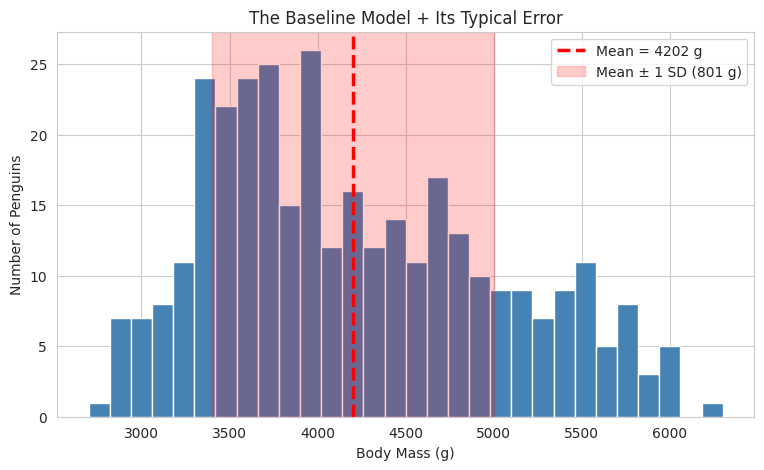

In [ ]:
# One last picture: the histogram with the mean AND a band of +/- 1 standard deviation
# around it. This is the region where "most" penguins live.
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(body_mass_g, bins=30, color='steelblue', edgecolor='white')
ax.axvline(mean_mass, color='red', linestyle='--', linewidth=2.5,
           label=f'Mean = {mean_mass:.0f} g')
ax.axvspan(mean_mass - std_dev, mean_mass + std_dev,
           alpha=0.2, color='red',
           label=f'Mean \u00b1 1 SD ({std_dev:.0f} g)')
ax.set_xlabel('Body Mass (g)')
ax.set_ylabel('Number of Penguins')
ax.set_title('The Baseline Model + Its Typical Error')
ax.legend()
plt.show()

---

## Putting It All Together

We now have a complete understanding of the **Baseline Model**.

> When a new penguin walks into the tent and we have no other information, we predict it will weigh about **4,207 g** (the **mean**). Based on the natural spread of penguin weights, we expect our guess to be off by roughly **801 g** (the **standard deviation**).

Here is the entire vocabulary of this notebook in one place:

| Concept | Symbol / Formula | What it means |
|---|---|---|
| Mean | $\bar{y}$ | The baseline prediction. |
| Error (deviation) | $y_i - \bar{y}$ | How wrong the baseline is for penguin $i$. |
| Total Sum of Squares | $\sum (y_i - \bar{y})^2$ | Total squared error of the baseline. |
| Variance | $\text{TSS}/N$ | *Average* squared error (in weird units). |
| Standard Deviation | $\sqrt{\text{Variance}}$ | Typical error, in the original units. |

### Why Any of This Matters for Regression

Every regression model we build from here on out is going to be judged against this baseline. The whole game of modeling is this:

> **Can we use *other* information, like a penguin's flipper length, or its species, to shrink that ~801 g of typical error?**

When we get to $R^2$ in a few notebooks, we'll see that it's literally a score that answers this question: *"Of the original Total Sum of Squares in the baseline model, how much of it did our new model explain away?"* Reducing TSS is our primary goal, and now you know exactly where TSS comes from.

**Next up:** In notebook `17_0_2`, we'll leave the one-dimensional world and start looking at pairs of variables, because to shrink that error, we need another variable to lean on.